# Étape 3 - Analyse non supervisée et labellisation faible

## Objectifs

- Charger les embeddings extraits à l'étape 2.
- Réduire la dimension des features pour visualiser la structure du corpus.
- Tester plusieurs configurations de clustering avec `KMeans` et `DBSCAN`.
- Évaluer les regroupements au moyen de l'ARI sur le sous-ensemble fortement labellisé.
- Produire une première labellisation faible du pool non annoté, sans jamais mélanger labels forts et labels faibles.

## Rappel méthodologique

- Les labels forts restent dans `label_strong` et `label_strong_name`.
- Les clusters et labels faibles sont stockés dans des colonnes séparées.
- L'ARI n'est calculé que sur le sous-ensemble `strong_labeled_pool`.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import umap

PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
for candidate in [PROJECT_ROOT_CANDIDATE, *PROJECT_ROOT_CANDIDATE.parents]:
    if (candidate / "src").exists() and (candidate / "environment.yml").exists():
        if str(candidate) not in sys.path:
            sys.path.append(str(candidate))
        break

from src.notebook_utils import (
    build_figure_saver,
    configure_notebook,
    ensure_directory,
    find_project_root,
    set_global_seed,
)

configure_notebook(display_max_columns=100, display_max_rows=100)


In [2]:
PROJECT_ROOT = find_project_root()
FEATURE_TABLE_PATH = PROJECT_ROOT / "data" / "processed" / "features" / "resnet18_feature_table.csv"
CLUSTERING_OUTPUT_DIR = ensure_directory(PROJECT_ROOT / "data" / "processed" / "clustering")
FIGURES_DIR = ensure_directory(PROJECT_ROOT / "reports" / "figures" / "clustering")

RANDOM_SEED = 42
SAVE_FIGURES = True
save_figure = build_figure_saver(FIGURES_DIR, enabled=SAVE_FIGURES)
set_global_seed(RANDOM_SEED)

PCA_COMPONENT_GRID = [2, 10, 30, 50, 100]
FINAL_KMEANS_COMPONENTS = 10
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1

DBSCAN_CONFIGS = [
    {"space": "pca10", "eps": 8.0, "min_samples": 10},
    {"space": "pca10", "eps": 8.0, "min_samples": 5},
    {"space": "umap2", "eps": 1.0, "min_samples": 5},
]

print(f"PROJECT_ROOT          : {PROJECT_ROOT}")
print(f"FEATURE_TABLE_PATH    : {FEATURE_TABLE_PATH}")
print(f"CLUSTERING_OUTPUT_DIR : {CLUSTERING_OUTPUT_DIR}")
print(f"FIGURES_DIR           : {FIGURES_DIR}")
print(f"PCA_COMPONENT_GRID    : {PCA_COMPONENT_GRID}")
print(f"FINAL_KMEANS_COMPONENTS : {FINAL_KMEANS_COMPONENTS}")


PROJECT_ROOT          : /home/maxime/projects/brainscan-semisupervised
FEATURE_TABLE_PATH    : /home/maxime/projects/brainscan-semisupervised/data/processed/features/resnet18_feature_table.csv
CLUSTERING_OUTPUT_DIR : /home/maxime/projects/brainscan-semisupervised/data/processed/clustering
FIGURES_DIR           : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering
PCA_COMPONENT_GRID    : [2, 10, 30, 50, 100]
FINAL_KMEANS_COMPONENTS : 10


In [3]:
def compute_noise_ratio(labels: np.ndarray) -> float:
    return float(np.mean(labels == -1))


def count_clusters(labels: np.ndarray) -> int:
    unique_labels = set(labels)
    return len(unique_labels) - (1 if -1 in unique_labels else 0)


def safe_silhouette(features: np.ndarray, labels: np.ndarray) -> float:
    valid_mask = labels != -1
    valid_labels = labels[valid_mask]

    if valid_mask.sum() < 2:
        return np.nan
    if len(np.unique(valid_labels)) < 2:
        return np.nan

    return float(silhouette_score(features[valid_mask], valid_labels))


def majority_vote_mapping(cluster_labels: np.ndarray, true_labels: np.ndarray) -> dict[int, int]:
    mapping: dict[int, int] = {}
    temp_df = pd.DataFrame({"cluster": cluster_labels, "true_label": true_labels})
    temp_df = temp_df.loc[temp_df["cluster"] != -1].copy()

    for cluster_id, cluster_df in temp_df.groupby("cluster"):
        mapping[int(cluster_id)] = int(cluster_df["true_label"].mode().iloc[0])

    return mapping


def map_clusters_to_weak_labels(cluster_labels: np.ndarray, mapping: dict[int, int], noise_value: int = -1) -> np.ndarray:
    weak_labels = []
    for cluster_id in cluster_labels:
        weak_labels.append(mapping.get(int(cluster_id), noise_value))
    return np.asarray(weak_labels, dtype=int)


def label_names_from_int(values: np.ndarray) -> np.ndarray:
    name_map = {0: "normal", 1: "cancer", -1: "noise_or_unknown"}
    return np.asarray([name_map.get(int(value), "unknown") for value in values])


def scatter_embedding(ax, frame: pd.DataFrame, x_col: str, y_col: str, hue_col: str, title: str, alpha: float = 0.75, s: int = 18) -> None:
    sns.scatterplot(
        data=frame,
        x=x_col,
        y=y_col,
        hue=hue_col,
        alpha=alpha,
        s=s,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)


## 1. Charger la table de features

On travaille ici à partir des embeddings ResNet18 produits à l'étape 2.

In [4]:
feature_table_df = pd.read_csv(FEATURE_TABLE_PATH)
feature_columns = [column for column in feature_table_df.columns if column.startswith("feat_")]

X = feature_table_df[feature_columns].to_numpy(dtype=np.float32)
strong_mask = feature_table_df["source_split"].eq("strong_labeled_pool").to_numpy()
y_strong = feature_table_df.loc[strong_mask, "label_strong"].astype(int).to_numpy()

overview_df = pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "feature_dim",
            "n_strong_labeled",
            "n_unlabeled",
        ],
        "value": [
            len(feature_table_df),
            len(feature_columns),
            int(strong_mask.sum()),
            int((~strong_mask).sum()),
        ],
    }
)

display(overview_df)
display(feature_table_df[["relative_path", "source_split", "label_group", "label_strong", "y_ssl"]].head(5))


,metric,value
0,n_rows,1506
1,feature_dim,512
2,n_strong_labeled,100
3,n_unlabeled,1406


,relative_path,source_split,label_group,label_strong,y_ssl
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1,1
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1,1
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1,1
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1,1
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1,1


## 2. Standardisation et PCA

Les embeddings sont standardisés avant la réduction de dimension et le clustering.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_SEED)
X_pca_full = pca_full.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
pca_variance_df = pd.DataFrame(
    {
        "n_components": np.arange(1, len(cumulative_variance) + 1),
        "explained_variance_ratio": pca_full.explained_variance_ratio_,
        "cumulative_explained_variance": cumulative_variance,
    }
)

pca_component_summary_df = pd.DataFrame(
    {
        "n_components": PCA_COMPONENT_GRID,
        "cumulative_explained_variance": [float(cumulative_variance[n - 1]) for n in PCA_COMPONENT_GRID],
    }
)

display(pca_component_summary_df)


,n_components,cumulative_explained_variance
0,2,0.163656
1,10,0.403644
2,30,0.613326
3,50,0.715905
4,100,0.845784


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_pca_cumulative_variance.png


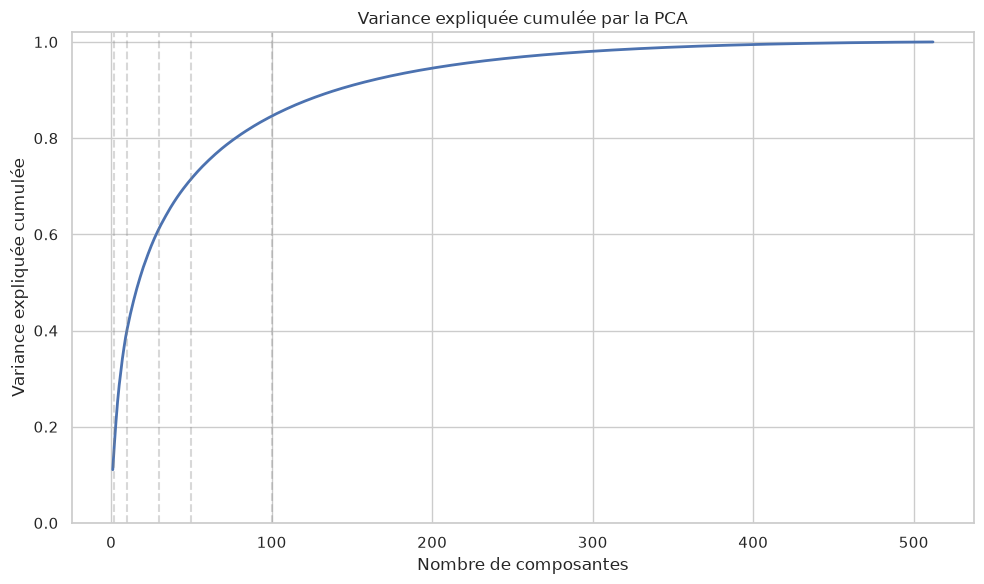

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pca_variance_df["n_components"], pca_variance_df["cumulative_explained_variance"], linewidth=2)
for n_components in PCA_COMPONENT_GRID:
    ax.axvline(n_components, color="grey", linestyle="--", alpha=0.3)
ax.set_title("Variance expliquée cumulée par la PCA")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée cumulée")
ax.set_ylim(0, 1.02)

plt.tight_layout()
save_figure(fig, "03_clustering_pca_cumulative_variance")
plt.show()


## 3. Espaces réduits pour clustering et visualisation

On construit ici plusieurs représentations :

- `PCA(10)` pour le clustering final KMeans ;
- `PCA(2)` pour une première vue globale ;
- `t-SNE(2)` et `UMAP(2)` pour la visualisation.

In [7]:
pca_embeddings: dict[int, np.ndarray] = {}
for n_components in PCA_COMPONENT_GRID:
    pca_embeddings[n_components] = PCA(n_components=n_components, random_state=RANDOM_SEED).fit_transform(X_scaled)

X_pca2 = pca_embeddings[2]
X_pca10 = pca_embeddings[10]
X_pca30 = pca_embeddings[30]
X_pca50 = pca_embeddings[50]

X_tsne2 = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_SEED,
).fit_transform(X_pca50)

X_umap2 = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric="euclidean",
    random_state=RANDOM_SEED,
).fit_transform(X_pca50)

embedding_viz_df = feature_table_df[["relative_path", "source_split", "label_group", "label_strong", "label_strong_name", "y_ssl"]].copy()
embedding_viz_df[["pca_1", "pca_2"]] = X_pca2
embedding_viz_df[["tsne_1", "tsne_2"]] = X_tsne2
embedding_viz_df[["umap_1", "umap_2"]] = X_umap2

display(embedding_viz_df.head(5))


/home/maxime/miniforge3/envs/brainscan/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,relative_path,source_split,label_group,label_strong,label_strong_name,y_ssl,pca_1,pca_2,tsne_1,tsne_2,umap_1,umap_2
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1,cancer,1,8.410507,-2.429402,26.110317,-38.131565,11.599341,-1.702838
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1,cancer,1,-8.558960,-4.020298,-23.014025,23.615805,-3.000437,4.613605
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1,cancer,1,-6.108311,-2.112532,-16.533564,27.560535,-2.754821,5.053170
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1,cancer,1,-1.959146,6.665945,-4.800709,19.698387,-1.170103,5.293432
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1,cancer,1,6.253914,14.879120,9.979671,40.691162,-1.805990,7.005115


## 4. Comparer plusieurs méthodes de clustering

Les métriques suivies sont :

- l'`ARI` sur le sous-ensemble fortement labellisé ;
- le `silhouette score` sur les clusters produits ;
- le nombre de clusters obtenus ;
- le taux de bruit pour `DBSCAN`.

In [8]:
comparison_rows = []

for n_components in PCA_COMPONENT_GRID:
    features_for_clustering = pca_embeddings[n_components]
    model = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init=20)
    labels = model.fit_predict(features_for_clustering)

    comparison_rows.append(
        {
            "method": "KMeans",
            "space": f"pca{n_components}",
            "ari_strong": float(adjusted_rand_score(y_strong, labels[strong_mask])),
            "silhouette": safe_silhouette(features_for_clustering, labels),
            "n_clusters": count_clusters(labels),
            "noise_ratio": 0.0,
        }
    )

kmeans_scaled = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init=20)
kmeans_scaled_labels = kmeans_scaled.fit_predict(X_scaled)
comparison_rows.append(
    {
        "method": "KMeans",
        "space": "scaled_features",
        "ari_strong": float(adjusted_rand_score(y_strong, kmeans_scaled_labels[strong_mask])),
        "silhouette": safe_silhouette(X_scaled, kmeans_scaled_labels),
        "n_clusters": count_clusters(kmeans_scaled_labels),
        "noise_ratio": 0.0,
    }
)

space_lookup = {
    "pca10": X_pca10,
    "umap2": X_umap2,
}

for config in DBSCAN_CONFIGS:
    features_for_clustering = space_lookup[config["space"]]
    model = DBSCAN(eps=config["eps"], min_samples=config["min_samples"])
    labels = model.fit_predict(features_for_clustering)

    comparison_rows.append(
        {
            "method": "DBSCAN",
            "space": config["space"],
            "ari_strong": float(adjusted_rand_score(y_strong, labels[strong_mask])),
            "silhouette": safe_silhouette(features_for_clustering, labels),
            "n_clusters": count_clusters(labels),
            "noise_ratio": compute_noise_ratio(labels),
            "eps": config["eps"],
            "min_samples": config["min_samples"],
        }
    )

clustering_comparison_df = pd.DataFrame(comparison_rows).sort_values(["ari_strong", "silhouette"], ascending=[False, False]).reset_index(drop=True)
display(clustering_comparison_df)


,method,space,ari_strong,silhouette,n_clusters,noise_ratio,eps,min_samples
0,KMeans,pca10,0.404052,0.228641,2,0.000000,NaN,NaN
1,KMeans,pca30,0.404052,0.152052,2,0.000000,NaN,NaN
2,KMeans,pca50,0.404052,0.130127,2,0.000000,NaN,NaN
3,KMeans,pca100,0.404052,0.110333,2,0.000000,NaN,NaN
4,KMeans,scaled_features,0.404052,0.093075,2,0.000000,NaN,NaN
5,KMeans,pca2,0.354144,0.546553,2,0.000000,NaN,NaN
6,DBSCAN,pca10,0.289368,0.251621,2,0.091633,8.0,10.0
7,DBSCAN,umap2,0.285424,0.743687,2,0.000000,1.0,5.0
8,DBSCAN,pca10,0.002427,NaN,1,0.053785,8.0,5.0


## 5. Retenir la meilleure configuration

Au vu de l'ARI, `KMeans` sur `PCA(10)` sert ici de configuration de référence pour générer une première labellisation faible.

In [9]:
best_kmeans_model = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init=20)
cluster_kmeans_pca10 = best_kmeans_model.fit_predict(X_pca10)

dbscan_reference_model = DBSCAN(eps=8.0, min_samples=10)
cluster_dbscan_pca10 = dbscan_reference_model.fit_predict(X_pca10)

kmeans_label_mapping = majority_vote_mapping(cluster_kmeans_pca10[strong_mask], y_strong)
weak_label_kmeans = map_clusters_to_weak_labels(cluster_kmeans_pca10, kmeans_label_mapping, noise_value=-1)
weak_label_name_kmeans = label_names_from_int(weak_label_kmeans)

dbscan_label_mapping = majority_vote_mapping(cluster_dbscan_pca10[strong_mask], y_strong)
weak_label_dbscan = map_clusters_to_weak_labels(cluster_dbscan_pca10, dbscan_label_mapping, noise_value=-1)
weak_label_name_dbscan = label_names_from_int(weak_label_dbscan)

clustering_results_df = embedding_viz_df.copy()
clustering_results_df["cluster_kmeans_pca10"] = cluster_kmeans_pca10.astype(int)
clustering_results_df["weak_label_kmeans"] = weak_label_kmeans.astype(int)
clustering_results_df["weak_label_name_kmeans"] = weak_label_name_kmeans
clustering_results_df["cluster_dbscan_pca10"] = cluster_dbscan_pca10.astype(int)
clustering_results_df["weak_label_dbscan"] = weak_label_dbscan.astype(int)
clustering_results_df["weak_label_name_dbscan"] = weak_label_name_dbscan

strong_eval_df = clustering_results_df.loc[strong_mask].copy()

mapping_summary_df = pd.DataFrame(
    {
        "cluster_id": list(kmeans_label_mapping.keys()),
        "mapped_strong_label": list(kmeans_label_mapping.values()),
        "mapped_strong_label_name": label_names_from_int(np.asarray(list(kmeans_label_mapping.values()))),
    }
)

display(mapping_summary_df)
display(clustering_results_df[["relative_path", "source_split", "cluster_kmeans_pca10", "weak_label_kmeans", "weak_label_name_kmeans"]].head(5))


,cluster_id,mapped_strong_label,mapped_strong_label_name
0,0,0,normal
1,1,1,cancer


,relative_path,source_split,cluster_kmeans_pca10,weak_label_kmeans,weak_label_name_kmeans
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,1,1,cancer
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,0,0,normal
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,0,0,normal
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,0,0,normal
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,1,1,cancer


In [10]:
strong_kmeans_crosstab = pd.crosstab(
    strong_eval_df["label_strong_name"],
    strong_eval_df["cluster_kmeans_pca10"],
    rownames=["label fort"],
    colnames=["cluster KMeans PCA10"],
)

strong_dbscan_crosstab = pd.crosstab(
    strong_eval_df["label_strong_name"],
    strong_eval_df["cluster_dbscan_pca10"],
    rownames=["label fort"],
    colnames=["cluster DBSCAN PCA10"],
)

display(strong_kmeans_crosstab)
display(strong_dbscan_crosstab)


cluster KMeans PCA10,0,1
label fort,,
cancer,16,34
normal,48,2


cluster DBSCAN PCA10,-1,0,1
label fort,,,
cancer,5,27,18
normal,1,2,47


## 6. Visualiser les regroupements

On compare ici la structure projetée du corpus et la cohérence visuelle entre clusters produits et labels forts disponibles.

Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_embeddings_vs_labels.png


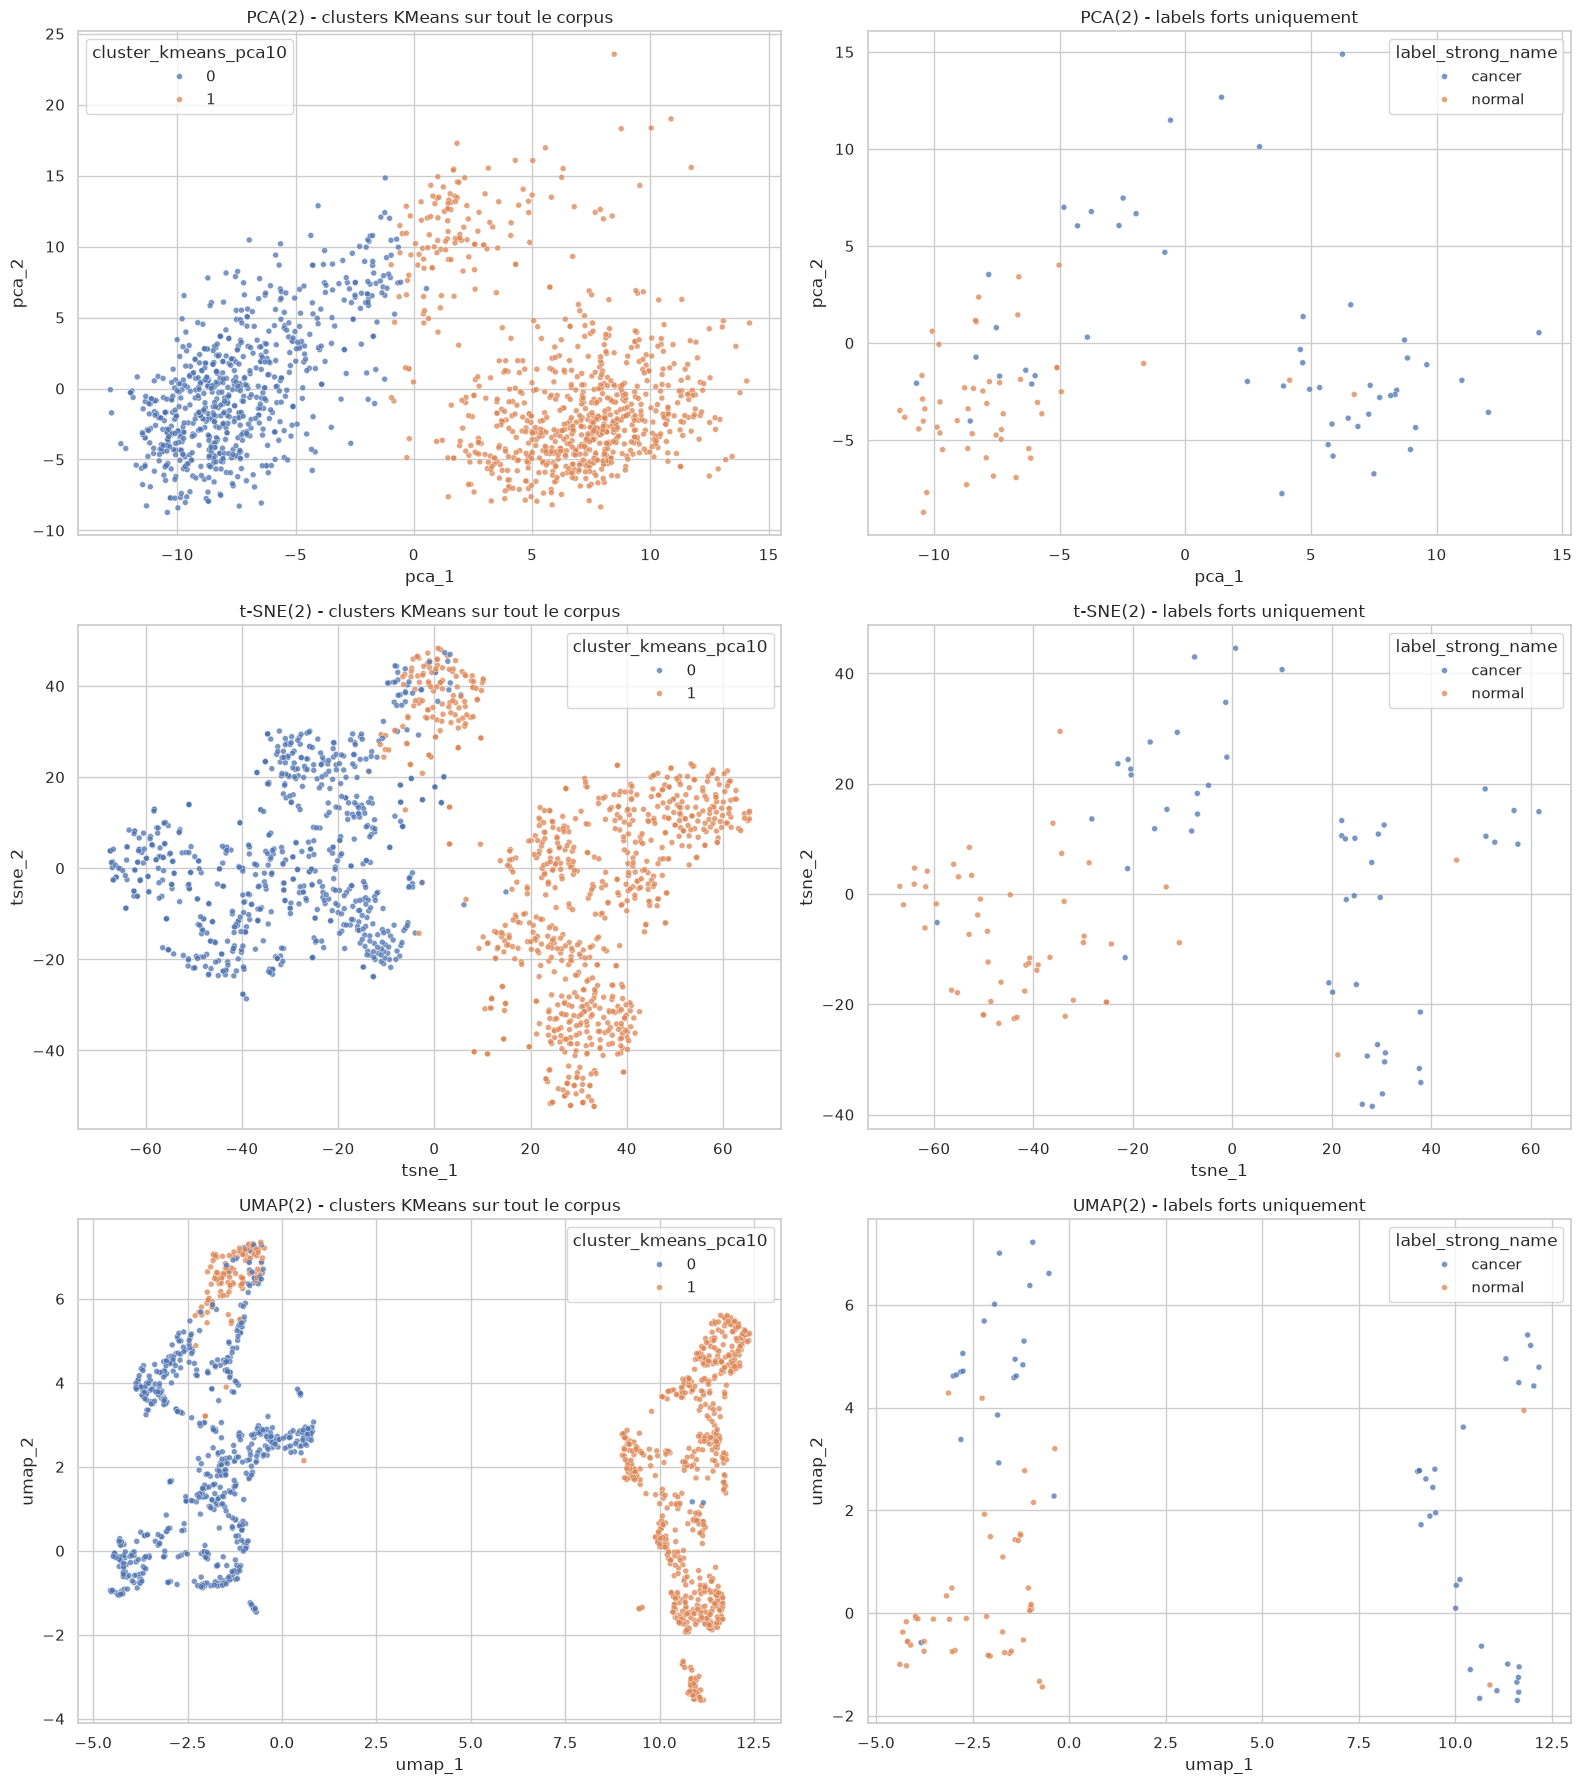

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

scatter_embedding(
    axes[0, 0],
    clustering_results_df,
    "pca_1",
    "pca_2",
    "cluster_kmeans_pca10",
    "PCA(2) - clusters KMeans sur tout le corpus",
)
scatter_embedding(
    axes[0, 1],
    strong_eval_df,
    "pca_1",
    "pca_2",
    "label_strong_name",
    "PCA(2) - labels forts uniquement",
)

scatter_embedding(
    axes[1, 0],
    clustering_results_df,
    "tsne_1",
    "tsne_2",
    "cluster_kmeans_pca10",
    "t-SNE(2) - clusters KMeans sur tout le corpus",
)
scatter_embedding(
    axes[1, 1],
    strong_eval_df,
    "tsne_1",
    "tsne_2",
    "label_strong_name",
    "t-SNE(2) - labels forts uniquement",
)

scatter_embedding(
    axes[2, 0],
    clustering_results_df,
    "umap_1",
    "umap_2",
    "cluster_kmeans_pca10",
    "UMAP(2) - clusters KMeans sur tout le corpus",
)
scatter_embedding(
    axes[2, 1],
    strong_eval_df,
    "umap_1",
    "umap_2",
    "label_strong_name",
    "UMAP(2) - labels forts uniquement",
)

plt.tight_layout()
save_figure(fig, "03_clustering_embeddings_vs_labels")
plt.show()


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_strong_label_crosstabs.png


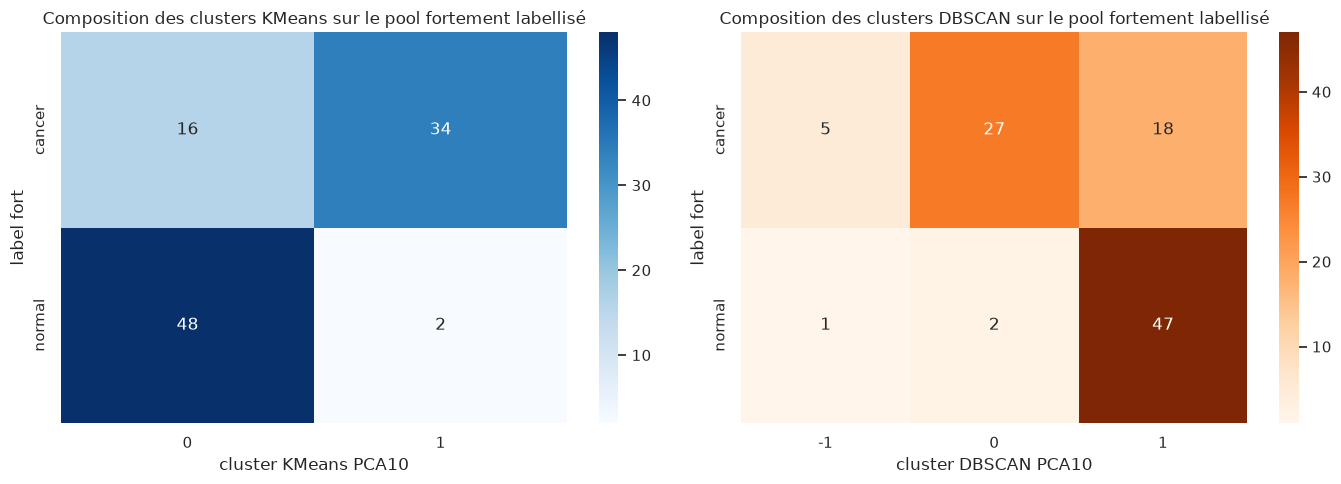

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(strong_kmeans_crosstab, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Composition des clusters KMeans sur le pool fortement labellisé")

sns.heatmap(strong_dbscan_crosstab, annot=True, fmt="d", cmap="Oranges", ax=axes[1])
axes[1].set_title("Composition des clusters DBSCAN sur le pool fortement labellisé")

plt.tight_layout()
save_figure(fig, "03_clustering_strong_label_crosstabs")
plt.show()


## 7. Export des artefacts

Les artefacts exportés serviront directement à l'étape 4 pour construire un premier jeu faiblement labellisé.

In [13]:
clustering_results_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_results.csv"
comparison_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_comparison.csv"
weak_unlabeled_path = CLUSTERING_OUTPUT_DIR / "resnet18_unlabeled_weak_labels_kmeans.csv"
pca_summary_path = CLUSTERING_OUTPUT_DIR / "resnet18_pca_component_summary.csv"
run_config_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_run_config.json"

weak_unlabeled_df = clustering_results_df.loc[
    clustering_results_df["source_split"] == "unlabeled_pool",
    [
        "relative_path",
        "source_split",
        "cluster_kmeans_pca10",
        "weak_label_kmeans",
        "weak_label_name_kmeans",
    ],
].copy()

run_config = {
    "feature_table_path": str(FEATURE_TABLE_PATH),
    "pca_component_grid": PCA_COMPONENT_GRID,
    "final_kmeans_components": FINAL_KMEANS_COMPONENTS,
    "tsne_perplexity": TSNE_PERPLEXITY,
    "umap_n_neighbors": UMAP_N_NEIGHBORS,
    "umap_min_dist": UMAP_MIN_DIST,
    "dbscan_configs": DBSCAN_CONFIGS,
    "kmeans_label_mapping": {str(key): int(value) for key, value in kmeans_label_mapping.items()},
}

clustering_results_df.to_csv(clustering_results_path, index=False)
clustering_comparison_df.to_csv(comparison_path, index=False)
weak_unlabeled_df.to_csv(weak_unlabeled_path, index=False)
pca_component_summary_df.to_csv(pca_summary_path, index=False)
run_config_path.write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

artifact_df = pd.DataFrame(
    {
        "artifact": [
            "clustering_results_csv",
            "clustering_comparison_csv",
            "weak_unlabeled_kmeans_csv",
            "pca_summary_csv",
            "run_config_json",
        ],
        "path": [
            str(clustering_results_path),
            str(comparison_path),
            str(weak_unlabeled_path),
            str(pca_summary_path),
            str(run_config_path),
        ],
    }
)

display(artifact_df)


,artifact,path
0,clustering_results_csv,/home/maxime/projects/brainscan-semisupervised...
1,clustering_comparison_csv,/home/maxime/projects/brainscan-semisupervised...
2,weak_unlabeled_kmeans_csv,/home/maxime/projects/brainscan-semisupervised...
3,pca_summary_csv,/home/maxime/projects/brainscan-semisupervised...
4,run_config_json,/home/maxime/projects/brainscan-semisupervised...


## 8. Observations et interprétation

### Ce que montre l'ARI

L'ARI permet ici d'évaluer dans quelle mesure les regroupements non supervisés retrouvent partiellement la séparation `normal` / `cancer` observée sur les labels forts. Un score non nul est déjà un signal encourageant, car le clustering n'a accès qu'aux embeddings visuels, sans supervision explicite.

### Lecture des résultats obtenus

- `KMeans` fournit ici les meilleurs résultats parmi les méthodes testées.
- `DBSCAN` est plus sensible au choix de ses hyperparamètres et peut produire beaucoup de bruit ou des partitions moins stables sur ce type d'embeddings.
- Les projections `PCA`, `t-SNE` et `UMAP` montrent une structuration partielle du corpus, mais pas une séparation parfaite entre les deux classes.

### Décision pour l'étape 4

La configuration `KMeans + PCA(10)` est retenue comme base pragmatique pour créer un premier jeu faiblement labellisé. Les labels faibles ainsi obtenus restent stockés dans des colonnes dédiées et ne remplacent jamais les labels forts.

### Précaution importante

Même si une labellisation faible a été produite pour le pool non annoté, elle doit être considérée comme une approximation utile pour amorcer l'étape semi-supervisée, et non comme une vérité terrain. L'évaluation finale devra toujours reposer sur un jeu de test strictement composé de labels forts jamais vus pendant l'entraînement.